In [1]:
import sys 
sys.path.append("/Users/shubham/Documents/Github/acceleration-flow-matching/src")


In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from vae import SpatialVae
from data_loader import train_loader
from tqdm import tqdm
from utils import visualize_samples
import torch.nn.functional as F

50000


In [6]:
# Loss Function for VAE

def vae_loss_spatial(x_recon, x, mu, logvar, beta=0.1):
    
    recon_loss = F.mse_loss(x_recon, x, reduction='mean')

    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) -logvar.exp())

    return recon_loss + beta * kl_loss, recon_loss, kl_loss

In [7]:
def train_spatial_vae(vae, train_loader, device='cpu', epochs=10, lr=1e-3):
    """Train spatial VAE"""
    optimizer = torch.optim.Adam(vae.parameters(), lr=lr)
    vae.train()
    
    for epoch in range(epochs):
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"VAE Epoch {epoch+1}/{epochs}")
        
        for x, _ in pbar:
            x = x.to(device)
            
            # Forward
            x_recon, mu, logvar, z = vae(x)
            
            # Loss
            loss, recon, kl = vae_loss_spatial(x_recon, x, mu, logvar)
            
            # Backward
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
            pbar.set_postfix({
                'loss': loss.item(),
                'recon': recon.item(),
                'kl': kl.item()
            })
        
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1} - Loss: {avg_loss:.6f}")
    
    return vae

In [8]:
device = 'cpu'

vae = SpatialVae(in_channels=3, latent_channels=16, scale_factor=4).to(device)
vae = train_spatial_vae(vae, train_loader, device=device, epochs=10)


VAE Epoch 1/10: 100%|██████████| 782/782 [01:31<00:00,  8.57it/s, loss=0.0387, recon=0.0219, kl=0.169]


Epoch 1 - Loss: 0.059898


VAE Epoch 2/10: 100%|██████████| 782/782 [01:43<00:00,  7.59it/s, loss=0.0411, recon=0.0219, kl=0.191]


Epoch 2 - Loss: 0.042751


VAE Epoch 3/10: 100%|██████████| 782/782 [01:50<00:00,  7.06it/s, loss=0.0436, recon=0.0245, kl=0.19] 


...

Epoch 8 - Loss: 0.039888


VAE Epoch 9/10: 100%|██████████| 782/782 [01:49<00:00,  7.12it/s, loss=0.0428, recon=0.0237, kl=0.19] 


Epoch 9 - Loss: 0.039785


VAE Epoch 10/10: 100%|██████████| 782/782 [01:50<00:00,  7.09it/s, loss=0.0476, recon=0.0264, kl=0.212]

Epoch 10 - Loss: 0.039659


In [27]:
import matplotlib.pyplot as plt
def visualize_reconstruction(vae, test_loader, device='cpu', num_samples=16):
    """Side-by-side original and reconstructed images"""
    vae.eval()
    
    x_test, _ = next(iter(test_loader))
    x_test = x_test[:num_samples].to(device)
    
    with torch.no_grad():
        x_recon, _, _, _ = vae(x_test)
    
    x_test_viz = (x_test.cpu() + 1) / 2
    x_recon_viz = (x_recon.cpu() + 1) / 2

    fig, axes = plt.subplots(2, num_samples // 2, figsize=(16, 6))
    fig.suptitle('VAE Reconstruction Comparison', fontsize=16)
    
    idx = 0
    for i in range(1):
        for j in range(num_samples // 2):
            axes[i, j].imshow(x_test_viz[idx].permute(1, 2, 0).numpy())
            axes[i, j].set_title(f"{'Original'} {idx}")
            axes[i, j].axis('off')
            idx += 1

        idx = 0
        for j in range(num_samples // 2):
            axes[i+1, j].imshow(x_recon_viz[idx].permute(1, 2, 0).numpy())
            axes[i+1, j].set_title(f"{'Reconstructed'} {idx}")
            axes[i+1, j].axis('off')
            idx += 1
    
    plt.tight_layout()
    plt.show()

In [28]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_dataset = datasets.CIFAR10(root='./data', train=False, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


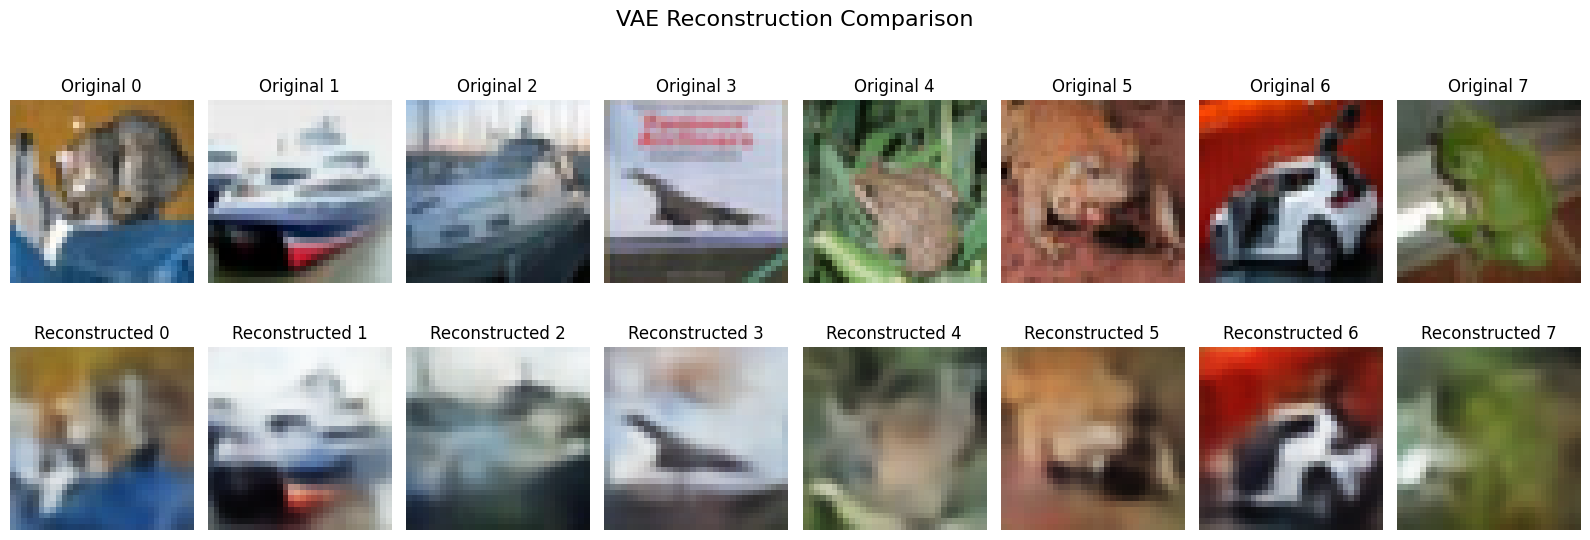

In [29]:
visualize_reconstruction(vae, test_loader)

In [30]:
torch.save(vae.state_dict(), 'spatial_vae.pth')